In [25]:
import pandas as pd
from sqlalchemy import create_engine
import sqlalchemy

# Database connection parameters
db_config = {
    'user': 'root',
    'password': 'mysql',
    'host': 'localhost',
    'database': 'company_database'
}
 
 # Create a connection to the database
try:
    engine = create_engine(f"mysql+mysqlconnector://{db_config['user']}:{db_config['password']}@{db_config['host']}/{db_config['database']}")
    connection = engine.connect()
    print("Database connection successful!")
except sqlalchemy.exc.SQLAlchemyError as e:
    print(f"Database connection failed: {e}")


 # Load data from the database into pandas DataFrames


Database connection successful!


In [26]:
employees = pd.read_sql("SELECT * FROM employees", engine)
department = pd.read_sql("SELECT * FROM department", engine)
attendance = pd.read_sql("SELECT * FROM attendance", engine)
performance = pd.read_sql("SELECT * FROM performance", engine)
sales = pd.read_sql("SELECT * FROM sales", engine)
projects = pd.read_sql("SELECT * FROM projects", engine)

print("✅ All Tables Loaded Successfully")


✅ All Tables Loaded Successfully


In [27]:
print("\nEmployees Preview:")
print(employees.head())

print("\nDepartment Preview:")
print(department.head())

print("\nAttendance Preview:")
print(attendance.head())

print("\nPerformance Preview:")
print(performance.head())

print("\nSales Preview:")
print(sales.head())

print("\nProjects Preview:")
print(projects.head())




Employees Preview:
   emp_id   emp_name  dept_id  salary   join_date
0       1     Pramod        1   55000  2025-01-10
1       2  Vaishnavi        2   65000  2024-05-12
2       3  Saujendra        7   48000  2025-03-18
3       4     Ankita        4   75000  2023-08-20
4       5       Ekta        3   60000  2025-01-11

Department Preview:
   dept_id  dept_name
0        1         IT
1        2    Finance
2        3         HR
3        4      Sales
4        5  Marketing

Attendance Preview:
   attendance_id  emp_id attendance_date   status
0              1       1      2026-05-01  Present
1              2       2      2026-05-01  Present
2              3       3      2026-05-01   Absent
3              4       4      2026-05-01  Present
4              5       5      2026-05-01  Present

Performance Preview:
   performance_id  emp_id  rating  review_year
0               1       1     4.2         2025
1               2       2     4.5         2025
2               3       3     3.8         2

In [28]:
# Merging to do analysis

emp_dept = pd.merge(employees, department, on="dept_id", how="left")
emp_perf = pd.merge(emp_dept, performance, on="emp_id", how="left")

print("\nMerged Dataset:")
print(emp_perf.head())


Merged Dataset:
   emp_id   emp_name  dept_id  salary   join_date  dept_name  performance_id  \
0       1     Pramod        1   55000  2025-01-10         IT               1   
1       2  Vaishnavi        2   65000  2024-05-12    Finance               2   
2       3  Saujendra        7   48000  2025-03-18  Insurance               3   
3       4     Ankita        4   75000  2023-08-20      Sales               4   
4       5       Ekta        3   60000  2025-01-11         HR               5   

   rating  review_year  
0     4.2         2025  
1     4.5         2025  
2     3.8         2025  
3     4.9         2025  
4     4.1         2025  


In [29]:
print("\nAvg Salary by Department:")
print(emp_perf.groupby("dept_name")["salary"].mean())

print("\nAvg Performance by Department:")
print(emp_perf.groupby("dept_name")["rating"].mean())




Avg Salary by Department:
dept_name
Finance       75142.857143
HR            65923.076923
IT            62214.285714
Insurance     52500.000000
Marketing     85750.000000
Operations    55909.090909
Sales         81076.923077
Support       50000.000000
Name: salary, dtype: float64

Avg Performance by Department:
dept_name
Finance       4.671429
HR            4.207692
IT            4.307143
Insurance     3.850000
Marketing     4.841667
Operations    3.927273
Sales         4.830769
Support       4.090909
Name: rating, dtype: float64


In [30]:
emp_dept = pd.merge(employees, department, on="dept_id", how="left")
emp_perf = pd.merge(emp_dept, performance, on="emp_id", how="left")
emp_att = pd.merge(emp_perf, attendance, on="emp_id", how="left")
emp_sales = pd.merge(emp_att, sales, on="emp_id", how="left")
emp_full = pd.merge(emp_sales, projects, on="dept_id", how="left")

print(emp_full.shape)
emp_full.head(10)

(1254, 18)


,emp_id,emp_name,dept_id,salary,join_date,dept_name,performance_id,rating,review_year,attendance_id,attendance_date,status,sale_id,sale_amount,sale_date,project_id,project_name,budget
0,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,1,AI Recruitment System,500000
1,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,9,Cloud Migration System,800000
2,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,17,Data Warehouse Pipeline,900000
3,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,25,Cybersecurity Monitoring,950000
4,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,33,Machine Learning Pipeline,870000
5,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,41,DevOps Automation,920000
6,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,49,Big Data Analytics Platform,990000
7,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,57,AI Chatbot Integration,910000
8,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,65,ETL Automation Framework,940000
9,1,Pramod,1,55000,2025-01-10,IT,1,4.2,2025,1,2026-05-01,Present,1,12000,2026-05-01,73,Data Governance System,980000


In [31]:
print(emp_full.isnull().sum().sort_values(ascending=False))

print("Duplicate rows:", emp_full.duplicated().sum())

print("\n")

print("Duplicate rows:", emp_full.duplicated().sum())

print("Data types:\n", emp_full.dtypes)


emp_id             0
emp_name           0
project_name       0
project_id         0
sale_date          0
sale_amount        0
sale_id            0
status             0
attendance_date    0
attendance_id      0
review_year        0
rating             0
performance_id     0
dept_name          0
join_date          0
salary             0
dept_id            0
budget             0
dtype: int64
Duplicate rows: 0


Duplicate rows: 0
Data types:
 emp_id               int64
emp_name            object
dept_id              int64
salary               int64
join_date           object
dept_name           object
performance_id       int64
rating             float64
review_year          int64
attendance_id        int64
attendance_date     object
status              object
sale_id              int64
sale_amount          int64
sale_date           object
project_id           int64
project_name        object
budget               int64
dtype: object


In [32]:
# Attendance percentage and KPIs with safe operations
import numpy as np
# Compute attendance counts
days_present = attendance.groupby("emp_id")["status"].apply(lambda x: (x == "Present").sum())
total_working_days = attendance.groupby("emp_id")["status"].count()
emp_full["days_present"] = emp_full["emp_id"].map(days_present)
emp_full["total_working_days"] = emp_full["emp_id"].map(total_working_days)
emp_full[["days_present", "total_working_days"]] = emp_full[["days_present", "total_working_days"]].fillna(0).astype(int)

emp_full["attendance_pct"] = np.where(emp_full["total_working_days"]>0,
                                        emp_full["days_present"]/emp_full["total_working_days"],
                                        np.nan)

print(emp_full[["emp_id", "days_present", "total_working_days", "attendance_pct"]].head())

# Projects completed: prefer per-employee if available, otherwise per-department
if 'emp_id' in projects.columns:
    projects_completed_emp = projects.groupby('emp_id')['project_id'].count()
    emp_full['projects_completed'] = emp_full['emp_id'].map(projects_completed_emp).fillna(0).astype(int)
else:
    projects_completed_dept = projects.groupby('dept_id')['project_id'].count()
    emp_full['projects_completed'] = emp_full['dept_id'].map(projects_completed_dept).fillna(0).astype(int)

emp_full['productivity_score'] = emp_full['rating'].fillna(emp_full['rating'].mean()) * emp_full['projects_completed']

# Safe divisions for revenue and salary efficiency
emp_full['revenue_per_project'] = np.where(emp_full['projects_completed']>0,
                                            emp_full['sale_amount']/emp_full['projects_completed'],
                                            np.nan)

emp_full['salary_efficiency'] = np.where(emp_full['salary']>0,
                                         emp_full['sale_amount']/emp_full['salary'],
                                         np.nan)

print(emp_full[["emp_id", "rating", "projects_completed", "productivity_score", "sale_amount", "salary", "revenue_per_project", "salary_efficiency"]].head())


   emp_id  days_present  total_working_days  attendance_pct
0       1             1                   1             1.0
1       1             1                   1             1.0
2       1             1                   1             1.0
3       1             1                   1             1.0
4       1             1                   1             1.0
   emp_id  rating  projects_completed  productivity_score  sale_amount  \
0       1     4.2                  13                54.6        12000   
1       1     4.2                  13                54.6        12000   
2       1     4.2                  13                54.6        12000   
3       1     4.2                  13                54.6        12000   
4       1     4.2                  13                54.6        12000   

   salary  revenue_per_project  salary_efficiency  
0   55000           923.076923           0.218182  
1   55000           923.076923           0.218182  
2   55000           923.076923         

In [33]:
dept_summary = emp_full.groupby("dept_name").agg({
    "salary": "mean",
    "rating": "mean",
    "attendance_pct": "mean",
    "sale_amount": "sum",
    "productivity_score": "mean"
})

print(dept_summary.sort_values("sale_amount", ascending=False))

                  salary    rating  attendance_pct  sale_amount  \
dept_name                                                         
Finance     75142.857143  4.671429        0.642857      3079700   
Sales       81076.923077  4.830769        0.615385      2891200   
IT          62214.285714  4.307143        0.714286      2730000   
HR          65923.076923  4.207692        0.615385      2398500   
Support     50000.000000  4.090909        0.454545      2254800   
Marketing   85750.000000  4.841667        0.583333      2217600   
Operations  55909.090909  3.927273        0.818182      2157600   
Insurance   52500.000000  3.850000        0.416667      2116800   

            productivity_score  
dept_name                       
Finance              60.728571  
Sales                62.800000  
IT                   55.992857  
HR                   54.700000  
Support              49.090909  
Marketing            58.100000  
Operations           47.127273  
Insurance            46.200000  

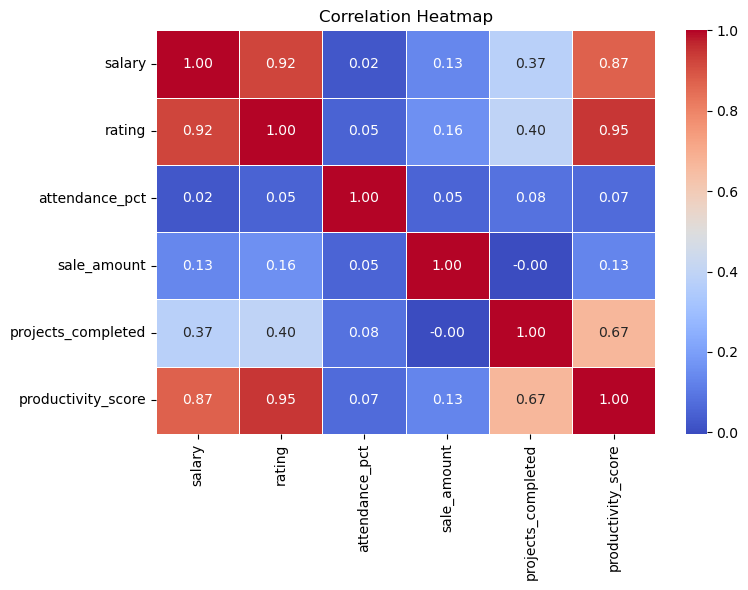

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = emp_full[[
    "salary", "rating", "attendance_pct",
    "sale_amount", "projects_completed",
    "productivity_score"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


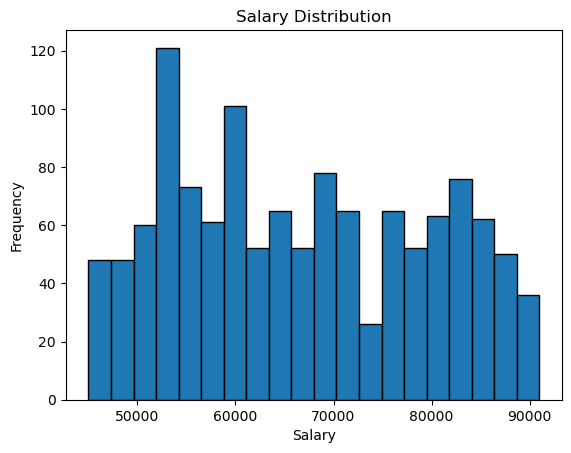

In [35]:
# Salary distribution of employees 
plt.figure()
plt.hist(emp_full["salary"], bins=20, edgecolor="black")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()



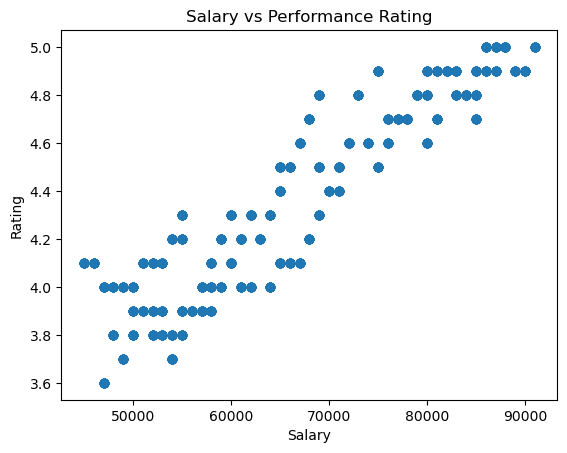

In [36]:
# Salary vs Performance Rating of employees
plt.figure()
plt.scatter(emp_full["salary"], emp_full["rating"])
plt.title("Salary vs Performance Rating")
plt.xlabel("Salary")
plt.ylabel("Rating")
plt.show()

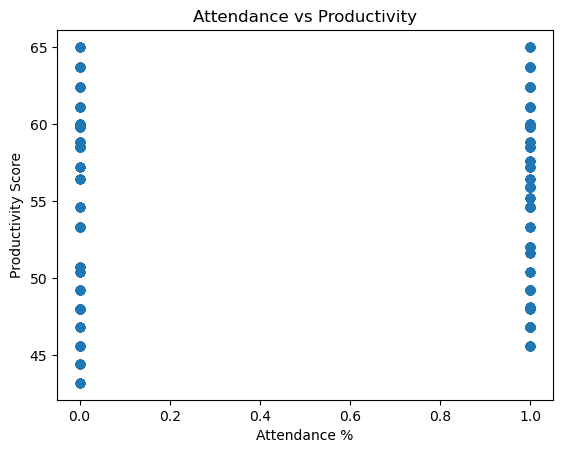

In [37]:
# Attendance vs Productivity of employees
plt.figure()
plt.scatter(emp_full["attendance_pct"], emp_full["productivity_score"])
plt.title("Attendance vs Productivity")
plt.xlabel("Attendance %")
plt.ylabel("Productivity Score")
plt.show()

In [38]:
from scipy.stats import pearsonr

# Calculate Pearson correlation between salary and rating
# performing Pearson correlation test
corr_val, p_val = pearsonr(emp_full["salary"], emp_full["rating"])

print("Correlation:", corr_val)
print("P-value:", p_val)

Correlation: 0.9237051788868846
P-value: 0.0


In [39]:
# Analyze impact of attendance on productivity 
# performing test type t-test

high_att = emp_full[emp_full["attendance_pct"] > emp_full["attendance_pct"].median()]
low_att = emp_full[emp_full["attendance_pct"] <= emp_full["attendance_pct"].median()]

print("High attendance avg productivity:", high_att["productivity_score"].mean())
print("Low attendance avg productivity:", low_att["productivity_score"].mean())

High attendance avg productivity: nan
Low attendance avg productivity: 54.881020733652306


In [40]:
# Employee segmentation based on performance and attendance
# performing rating and attendance based segmentation

def segment(row):
    if row["rating"] > 4 and row["attendance_pct"] > 0.9:
        return "High Performer"
    elif row["rating"] > 3:
        return "Average Performer"
    else:
        return "Low Performer"

emp_full["segment"] = emp_full.apply(segment, axis=1)

print(emp_full["segment"].value_counts())

segment
Average Performer    683
High Performer       571
Name: count, dtype: int64


In [41]:
hr = emp_full.copy()

# Normalize key metrics
hr["attendance_pct"] = hr["attendance_pct"].fillna(hr["attendance_pct"].mean())
hr["rating"] = hr["rating"].fillna(hr["rating"].mean())
hr["salary_efficiency"] = hr["salary_efficiency"].fillna(hr["salary_efficiency"].mean())

In [42]:
# Normalize into risk components (higher = better performance, so invert for risk)
hr["attendance_risk"] = 1 - hr["attendance_pct"]
hr["performance_risk"] = 5 - hr["rating"]  # assuming rating is out of 5
hr["efficiency_risk"] = 1 / (hr["salary_efficiency"] + 0.01)
hr["attrition_risk_score"] = hr[["attendance_risk", "performance_risk", "efficiency_risk"]].mean(axis=1)

print(hr[["emp_id", "attendance_risk", "performance_risk", "efficiency_risk", "attrition_risk_score"]].head())



   emp_id  attendance_risk  performance_risk  efficiency_risk  \
0       1              0.0               0.8          4.38247   
1       1              0.0               0.8          4.38247   
2       1              0.0               0.8          4.38247   
3       1              0.0               0.8          4.38247   
4       1              0.0               0.8          4.38247   

   attrition_risk_score  
0               1.72749  
1               1.72749  
2               1.72749  
3               1.72749  
4               1.72749  


In [43]:
hr["attrition_risk_score"] = (
    0.4 * hr["attendance_risk"] +
    0.4 * hr["performance_risk"] +
    0.2 * hr["efficiency_risk"]
)

# Scale to 0–100
hr["attrition_risk_score"] = (
    hr["attrition_risk_score"] - hr["attrition_risk_score"].min()
) / (
    hr["attrition_risk_score"].max() - hr["attrition_risk_score"].min()
) * 100


print(hr[["emp_id", "attrition_risk_score"]].head())



   emp_id  attrition_risk_score
0       1             37.434565
1       1             37.434565
2       1             37.434565
3       1             37.434565
4       1             37.434565


In [44]:
def risk_band(score):
    if score >= 70:
        return "High Risk"
    elif score >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

hr["attrition_segment"] = hr["attrition_risk_score"].apply(risk_band)

hr["attrition_segment"].value_counts()

attrition_segment
Low Risk       578
Medium Risk    539
High Risk      137
Name: count, dtype: int64

In [45]:
hr.sort_values("attrition_risk_score", ascending=False)[
    ["emp_id", "dept_name", "attrition_risk_score", "attrition_segment"]
].head(10)

print(hr[["emp_id", "dept_name", "attrition_risk_score", "attrition_segment"]].head(10))


   emp_id dept_name  attrition_risk_score attrition_segment
0       1        IT             37.434565          Low Risk
1       1        IT             37.434565          Low Risk
2       1        IT             37.434565          Low Risk
3       1        IT             37.434565          Low Risk
4       1        IT             37.434565          Low Risk
5       1        IT             37.434565          Low Risk
6       1        IT             37.434565          Low Risk
7       1        IT             37.434565          Low Risk
8       1        IT             37.434565          Low Risk
9       1        IT             37.434565          Low Risk


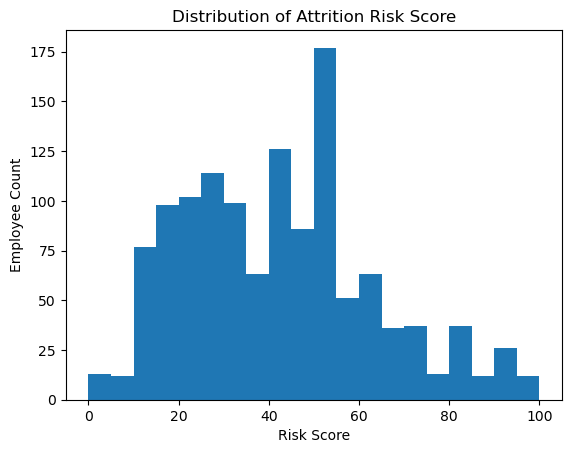

Descriptive stats:
       productivity_score  attendance_pct
count         1254.000000     1254.000000
mean            54.881021        0.611643
std              6.170129        0.487571
min             43.200000        0.000000
25%             49.200000        0.000000
50%             55.900000        1.000000
75%             59.800000        1.000000
max             65.000000        1.000000
Not enough data in one of the groups to perform tests.


In [46]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(hr["attrition_risk_score"], bins=20)
plt.title("Distribution of Attrition Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Employee Count")
plt.show()
# Descriptive stats and hypothesis test for attendance vs productivity
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

print('Descriptive stats:')
print(emp_full[['productivity_score','attendance_pct']].describe())

# Prepare groups
att_median = emp_full['attendance_pct'].median()
high_att = emp_full[emp_full['attendance_pct'] > att_median]['productivity_score'].dropna()
low_att = emp_full[emp_full['attendance_pct'] <= att_median]['productivity_score'].dropna()

# Assumption checks (normality and equal variances)
if len(high_att) >= 3 and len(low_att) >= 3:
    stat_h, p_h = shapiro(high_att)
    stat_l, p_l = shapiro(low_att)
    print(f'High attendance Shapiro p-value: {p_h:.4f}')
    print(f'Low attendance Shapiro p-value: {p_l:.4f}')

    lev_stat, lev_p = levene(high_att, low_att)
    print(f'Levene test p-value: {lev_p:.4f}')

    # Choose test
    if p_h > 0.05 and p_l > 0.05:
        # parametric t-test
        equal_var = True if lev_p > 0.05 else False
        tstat, pval = ttest_ind(high_att, low_att, equal_var=equal_var, nan_policy='omit')
        print(f'T-test p-value: {pval:.4f}')
    else:
        # non-parametric
        stat, pval = mannwhitneyu(high_att, low_att, alternative='two-sided')
        print(f'Mann-Whitney p-value: {pval:.4f}')

    # Report means
    print('High attendance mean productivity:', high_att.mean())
    print('Low attendance mean productivity:', low_att.mean())
else:
    print('Not enough data in one of the groups to perform tests.')
